# AutoEncoder

## Dataset Creation

## Verify Data inside .npz files

In [2]:
# --- 0) Notebook setup (paths, reproducibility, display) ---
from __future__ import annotations

import os
from pathlib import Path

import numpy as np

# Root of this repo (assumes this notebook lives at repo root)
REPO_ROOT = Path.cwd()
PROCESSED_DIR = REPO_ROOT / "processed_data"

# Subject IDs present in processed_data/
SUBJECTS = ["CSI1", "CSI2", "CSI3", "CSI4"]

# Common Schaefer parcellations in this repo
SCHAEFER_VARIANTS = [ "schaefer1014"]

# Safer default: prefer NOT unpickling. If an npz contains object arrays,
# we'll either (a) skip those keys or (b) enable pickle if requested.
ALLOW_PICKLE = False
SKIP_OBJECT_ARRAYS = True

print("REPO_ROOT:", REPO_ROOT)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())
print("Subjects:", SUBJECTS)
print("Schaefer variants:", SCHAEFER_VARIANTS)

def _npz_path(subject: str, variant: str) -> Path:
    """Return path to a per-subject Schaefer .npz file."""
    return PROCESSED_DIR / subject / f"{subject}_{variant}.npz"


def _visual_rois_path(subject: str) -> Path:
    """Return path to a per-subject visual ROIs .npz file."""
    return PROCESSED_DIR / subject / f"{subject}_visual_rois.npz"


def _require_exists(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")

def list_available_npzs(subject: str) -> dict[str, Path]:
    """List available npz files for a given subject."""
    subj_dir = PROCESSED_DIR / subject
    if not subj_dir.exists():
        return {}
    out: dict[str, Path] = {}
    for p in sorted(subj_dir.glob("*.npz")):
        out[p.name] = p
    return out


for s in SUBJECTS:
    files = list_available_npzs(s)
    print(f"\n{s}: {len(files)} npz files")
    for name in list(files)[:10]:
        print(" -", name)
    if len(files) > 10:
        print("   ...")

def load_npz(
    path: Path,
    *,
    allow_pickle: bool | None = None,
    skip_object_arrays: bool | None = None,
) -> dict[str, np.ndarray]:
    """Load npz and return a {key: array} dict (eagerly loaded).

    Some of the repo's .npz files may contain object arrays (e.g., strings).
    By default we avoid pickle; if object arrays are present we skip them.

    Set allow_pickle=True to load everything (less safe, but sometimes needed).
    """
    _require_exists(path)
    if allow_pickle is None:
        allow_pickle = ALLOW_PICKLE
    if skip_object_arrays is None:
        skip_object_arrays = SKIP_OBJECT_ARRAYS

    out: dict[str, np.ndarray] = {}
    with np.load(path, allow_pickle=allow_pickle) as f:
        for k in f.files:
            try:
                arr = f[k]
            except ValueError as e:
                # Typical: "Object arrays cannot be loaded when allow_pickle=False"
                if skip_object_arrays:
                    print(f"[load_npz] Skipping key '{k}' in {path.name}: {e}")
                    continue
                raise

            if skip_object_arrays and isinstance(arr, np.ndarray) and arr.dtype == object:
                print(f"[load_npz] Skipping object array key '{k}' in {path.name}")
                continue
            out[k] = arr
    return out


def describe_npz(npz: dict[str, np.ndarray], max_keys: int = 20) -> None:
    keys = list(npz.keys())
    print(f"Keys ({len(keys)}):", keys[:max_keys], "..." if len(keys) > max_keys else "")
    for k in keys[:max_keys]:
        a = npz[k]
        print(f"  {k:>24}  shape={a.shape}  dtype={a.dtype}")


# Pick one subject+variant to inspect first
SUBJECT = SUBJECTS[0]
VARIANT = SCHAEFER_VARIANTS[0]
PATH = _npz_path(SUBJECT, VARIANT)
print("Inspecting:", PATH)
npz0 = load_npz(PATH)
describe_npz(npz0)

def find_data_array(npz: dict[str, np.ndarray]) -> tuple[str, np.ndarray]:
    """Heuristic: find the 'main' 2D array likely holding betas/voxel/ROI features."""
    # Common candidates
    preferred = [
        "X",
        "data",
        "betas",
        "features",
        "fmri",
        "roi_data",
        "roi_betas",
    ]
    for k in preferred:
        if k in npz and npz[k].ndim >= 2:
            return k, npz[k]

    # Fallback: choose the largest numeric array
    best_k = None
    best = None
    best_size = -1
    for k, a in npz.items():
        if not isinstance(a, np.ndarray):
            continue
        if a.dtype.kind not in "iufb":
            continue
        if a.size > best_size and a.ndim >= 2:
            best_k, best, best_size = k, a, a.size
    if best_k is None:
        raise ValueError("Couldn't find a plausible numeric 2D+ data array in npz")
    return best_k, best


data_key, X = find_data_array(npz0)
print("Main data key:", data_key)
print("X:", X.shape, X.dtype)

# Basic shape contract we want to validate:
# - samples dimension == number of images/trials
# - feature dimension == parcels/ROIs/voxels
print("n_samples:", X.shape[0])
print("n_features:", X.shape[1] if X.ndim >= 2 else None)

REPO_ROOT: /home/mariop/Documents/Programming/bold5000-gan
PROCESSED_DIR exists: True
Subjects: ['CSI1', 'CSI2', 'CSI3', 'CSI4']
Schaefer variants: ['schaefer1014']

CSI1: 4 npz files
 - CSI1_schaefer1014.npz
 - CSI1_schaefer400.npz
 - CSI1_schaefer414.npz
 - CSI1_visual_rois.npz

CSI2: 4 npz files
 - CSI2_schaefer1014.npz
 - CSI2_schaefer400.npz
 - CSI2_schaefer414.npz
 - CSI2_visual_rois.npz

CSI3: 4 npz files
 - CSI3_schaefer1014.npz
 - CSI3_schaefer400.npz
 - CSI3_schaefer414.npz
 - CSI3_visual_rois.npz

CSI4: 4 npz files
 - CSI4_schaefer1014.npz
 - CSI4_schaefer400.npz
 - CSI4_schaefer414.npz
 - CSI4_visual_rois.npz
Inspecting: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI1/CSI1_schaefer1014.npz
[load_npz] Skipping key 'labels' in CSI1_schaefer1014.npz: Object arrays cannot be loaded when allow_pickle=False
Keys (7): ['betas', 'imgnames', 'subject', 'sessions', 'local_idxs', 'dataset_sources', 'parcel_names'] 
                     betas  shape=(5254, 1014)  dt

## Map Trial to Image

In [3]:
# --- 1) Match Schaefer1014 trials to raw stimulus images ---
# Goal: given an imgnames entry (e.g., "n01930112_19568.JPEG"), return the on-disk path.

import glob
from functools import lru_cache

# This should match the constant used in `CLIP_Data_Pipeline.ipynb`
STIMULI_DIR = "/media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli"


def reconstruct_raw_imagename(name) -> str:
    """Normalize imgnames entries to a base filename.

    In BOLD5000-style metadata this is usually already something like:
      - 'n01930112_19568.JPEG'
      - 'COCO_train2014_000000123456.jpg'

    This function strips folders if they appear and ensures it's a plain basename.
    """
    # Handle bytes (common in npz allow_pickle=True)
    if isinstance(name, (bytes, np.bytes_)):
        name = name.decode("utf-8", errors="replace")
    name = str(name)
    return os.path.basename(name)


@lru_cache(maxsize=1)
def _build_image_map(stimuli_dir: str = STIMULI_DIR) -> dict[str, str]:
    """Index all image files under the stimuli directory.

    Returns:
        dict mapping basename -> absolute path
    """
    if not os.path.exists(stimuli_dir):
        raise FileNotFoundError(
            "STIMULI_DIR not found. Update STIMULI_DIR to where BOLD5000 stimuli live on this machine. "
            f"Got: {stimuli_dir}"
        )

    image_paths = (
        glob.glob(f"{stimuli_dir}/**/*.jpg", recursive=True)
        + glob.glob(f"{stimuli_dir}/**/*.jpeg", recursive=True)
        + glob.glob(f"{stimuli_dir}/**/*.JPEG", recursive=True)
        + glob.glob(f"{stimuli_dir}/**/*.png", recursive=True)
    )

    # basename -> full path (if collisions exist, last one wins; we'll warn below)
    image_map: dict[str, str] = {}
    collisions = 0
    for p in image_paths:
        b = os.path.basename(p)
        if b in image_map and image_map[b] != p:
            collisions += 1
        image_map[b] = p

    if collisions:
        print(f"[warn] basename collisions encountered while indexing: {collisions}")

    print(f"Indexed {len(image_paths)} images under {stimuli_dir}")
    return image_map


def resolve_raw_image_path(imagename: str, *, stimuli_dir: str = STIMULI_DIR) -> str:
    """Deliverable: given an image name, return the absolute raw image path.

    Args:
        imagename: string or bytes name from the fMRI metadata; may include folders.
        stimuli_dir: root directory containing Presented_Stimuli (defaults to repo convention).

    Returns:
        Absolute path on disk.

    Raises:
        FileNotFoundError if not found.
    """
    base = reconstruct_raw_imagename(imagename)
    image_map = _build_image_map(stimuli_dir)
    if base not in image_map:
        raise FileNotFoundError(
            f"Image '{base}' not found under stimuli_dir='{stimuli_dir}'. "
            "If the drive is mounted elsewhere, update STIMULI_DIR."
        )
    return image_map[base]


# --- Sanity check: do Schaefer1014 NPZs contain imgnames? ---
# We load with allow_pickle=True just for metadata keys like imgnames.

SUBJECT_FOR_IMG_CHECK = SUBJECTS[0]
S1014 = load_npz(_npz_path(SUBJECT_FOR_IMG_CHECK, "schaefer1014"), allow_pickle=True, skip_object_arrays=False)

img_key_candidates = ["imgnames", "image_names", "images", "stimuli", "stim_names"]
img_key = next((k for k in img_key_candidates if k in S1014), None)

if img_key is None:
    print("Couldn't find an image-name key in the schaefer1014 npz.")
    print("Available keys:", list(S1014.keys())[:50])
else:
    imgnames = S1014[img_key]
    print(f"Found image names under key '{img_key}' with shape {imgnames.shape} dtype={imgnames.dtype}")
    sample = reconstruct_raw_imagename(imgnames[0])
    print("Sample reconstructed name:", sample)

    # Try resolving a single image path (will raise if STIMULI_DIR isn't correct/mounted)
    try:
        p = resolve_raw_image_path(sample)
        print("Resolved path:", p)
    except FileNotFoundError as e:
        print("Resolve failed (expected if stimuli drive isn't mounted here):")
        print(" ", e)


Found image names under key 'imgnames' with shape (5254,) dtype=<U31
Sample reconstructed name: n01930112_19568.JPEG
Resolve failed (expected if stimuli drive isn't mounted here):
  STIMULI_DIR not found. Update STIMULI_DIR to where BOLD5000 stimuli live on this machine. Got: /media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli


# CLIP

In [11]:
# --- 2) CLIP: image filepath -> embedding ---
# Deliverable: clip_embed_image(image_path) -> np.ndarray

from functools import lru_cache

import numpy as np
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPVisionModelWithProjection


@lru_cache(maxsize=4)
def _load_clip(model_id: str = "openai/clip-vit-large-patch14", device_str: str | None = None):
    """Load CLIP model + processor once per kernel.

    device_str:
      - None: auto (cuda if available else cpu)
      - 'cpu' or 'cuda': force
    """
    if device_str is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device_str)

    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPVisionModelWithProjection.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model, device


def clip_embed_image(
    image_path: str,
    *,
    model_id: str = "openai/clip-vit-large-patch14",
    device: str | None = None,
    fallback_to_cpu: bool = True,
) -> np.ndarray:
    """Compute a CLIP image embedding from a local image filepath.

    Args:
        image_path: absolute path to an image file.
        model_id: HF model id; default matches `CLIP_Data_Pipeline.ipynb`.
        device: None|'cuda'|'cpu'. None auto-selects.
        fallback_to_cpu: if True, retry on CPU when a CUDA error occurs.

    Returns:
        embedding: shape (768,) float32 numpy array for ViT-L/14.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image path does not exist: {image_path}")

    def _run(dev: str | None) -> np.ndarray:
        processor, model, torch_device = _load_clip(model_id, dev)
        img = Image.open(image_path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(torch_device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            emb = outputs.image_embeds.squeeze(0).detach().cpu().numpy().astype(np.float32)
        return emb

    try:
        return _run(device)
    except RuntimeError as e:
        msg = str(e)
        if fallback_to_cpu and ("CUDA" in msg or "cuda" in msg) and (device is None or device == "cuda"):
            # Best-effort cleanup then retry on CPU
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass
            return _run("cpu")
        raise


# --- Optional smoke test: first Schaefer1014 image -> path -> CLIP embedding ---
if 'imgnames' in globals() and len(imgnames) > 0:
    try:
        first_name = reconstruct_raw_imagename(imgnames[0])
        first_path = resolve_raw_image_path(first_name)
        emb = clip_embed_image(first_path)
        print("first_name:", first_name)
        print("first_path:", first_path)
        print("embedding shape:", emb.shape, "dtype:", emb.dtype, "norm:", float(np.linalg.norm(emb)))
    except FileNotFoundError as e:
        print("Smoke test skipped (image not found / stimuli not mounted):")
        print(" ", e)


Loading weights: 100%|██████████| 392/392 [00:00<00:00, 9619.18it/s]
CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.embeddings.position_ids                         | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.b

first_name: n01930112_19568.JPEG
first_path: /media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli/ImageNet/n01930112_19568.JPEG
embedding shape: (768,) dtype: float32 norm: 17.427244186401367


## Create ClipEmbeddings.json

We create a file ClipEmbeddings.json that contains the resulting CLIP embedding for every image in our dataset. 
It also contains the human readable labels, and path to the raw image

In [ ]:
# --- 3) Build ClipEmbeddings.json (imgname -> path + CLIP embedding + labels) ---

import json
import re
from collections import defaultdict

OUT_JSON = REPO_ROOT / "ClipEmbeddings.json"
OUT_JSON_TMP = REPO_ROOT / "ClipEmbeddings.partial.json"
SEMANTIC_LABELS_JSON = REPO_ROOT / "SemanticLabels.json"
LABEL_MAPPINGS_DIR = REPO_ROOT / "label_mappings"

# Set this True if you want to overwrite existing output.
FORCE_REBUILD = False

# For reliability, default to CPU for the full build (GPU can be faster but may error on long runs).
# You can set to 'cuda' if you want, and it will still fallback-to-CPU on CUDA errors.
EMBED_DEVICE: str | None = "cpu"  # 'cpu' | 'cuda' | None

# Save partial progress every N records
CHECKPOINT_EVERY = 100

if OUT_JSON.exists() and not FORCE_REBUILD:
    print(f"{OUT_JSON} already exists. Set FORCE_REBUILD=True to regenerate.")
else:
    # 1) Load semantic label mapping (coarse category -> {aliases, labels})
    # Note: we keep this loaded because it can be useful as a fallback/secondary tagging scheme.
    with open(SEMANTIC_LABELS_JSON, "r") as f:
        semantic_map = json.load(f)

    # Build: fine_label -> [coarse_categories]
    fine_to_coarse: dict[str, list[str]] = defaultdict(list)
    for coarse, payload in semantic_map.items():
        for fine in payload.get("labels", []):
            fine_to_coarse[str(fine)].append(coarse)

    # 2) Load authoritative label mappings (mirrors Autoencoder_RSA_firstattempt.ipynb)
    def _load_imagenet_synset_to_label(mappings_dir: Path) -> dict[str, str]:
        inet_path = mappings_dir / "imagenet_class_index.json"
        if not inet_path.exists():
            raise FileNotFoundError(
                f"Missing {inet_path}. Ensure label_mappings/ contains imagenet_class_index.json"
            )
        with open(inet_path, "r") as f:
            raw = json.load(f)
        # raw: idx -> [synset, label]
        return {v[0]: v[1] for v in raw.values()}

    def _load_coco_img_to_categories(mappings_dir: Path) -> dict[int, list[str]]:
        coco_path = mappings_dir / "instances_train2014.json"
        if not coco_path.exists():
            raise FileNotFoundError(
                f"Missing {coco_path}. Ensure label_mappings/ contains instances_train2014.json"
            )
        with open(coco_path, "r") as f:
            coco_data = json.load(f)
        cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
        img_to_cats: dict[int, list[str]] = {}
        for ann in coco_data["annotations"]:
            img_id = int(ann["image_id"])
            cat_name = cat_id_to_name.get(int(ann["category_id"]), "unknown")
            img_to_cats.setdefault(img_id, [])
            if cat_name not in img_to_cats[img_id]:
                img_to_cats[img_id].append(cat_name)
        return img_to_cats

    imagenet_synset_to_label = _load_imagenet_synset_to_label(LABEL_MAPPINGS_DIR)
    coco_img_to_categories = _load_coco_img_to_categories(LABEL_MAPPINGS_DIR)

    def human_labels_for_imgname(imgname: str) -> list[str]:
        """Human-readable label(s) for an image name.

        Priority is the same as in Autoencoder_RSA_firstattempt.ipynb:
          - COCO filename -> COCO category list (multi-label)
          - ImageNet filename -> ImageNet class label
          - Scene filename -> cleaned basename

        We optionally *append* coarse semantic categories from SemanticLabels.json when we can infer them.
        """
        base = reconstruct_raw_imagename(imgname)

        # ImageNet: starts with n followed by digits, then underscore
        if re.match(r"^n\d+_", base):
            synset = base.split("_")[0]
            fine = imagenet_synset_to_label.get(synset, synset)
            out = [fine]
        # COCO: filename contains 'COCO' and includes ID digits
        elif "COCO" in base:
            m = re.search(r"(\d{6,12})", base)
            img_id = int(m.group(1)) if m else -1
            out = coco_img_to_categories.get(img_id, [])
            if not out:
                out = [f"COCO image {img_id}"]
        # Scene / SUN / other
        else:
            scene = os.path.splitext(base)[0]
            scene = re.sub(r"\d+", "", scene)
            scene = re.sub(r"([a-z])([A-Z])", r"\1 \2", scene)
            scene = scene.replace("_", " ").replace("-", " ")
            scene = re.sub(r"\s+", " ", scene).strip()
            out = [scene.title() or base]

        # Optional: semantic coarse category guess from tokens (kept conservative)
        name_no_ext = os.path.splitext(base)[0]
        tokens = set(name_no_ext.replace("-", "_").split("_"))
        for t in list(tokens):
            if t in fine_to_coarse:
                out.extend(fine_to_coarse[t])

        # De-dupe while preserving order
        seen = set()
        out2 = []
        for x in out:
            if x not in seen:
                seen.add(x)
                out2.append(x)
        return out2

    # 3) Get all image names from Schaefer1014 metadata across subjects.
    all_imgnames = []
    for s in SUBJECTS:
        meta = load_npz(_npz_path(s, "schaefer1014"), allow_pickle=True, skip_object_arrays=False)
        if "imgnames" not in meta:
            raise KeyError(f"Expected 'imgnames' in {s} schaefer1014 npz, found keys={list(meta.keys())}")
        all_imgnames.append(meta["imgnames"])

    all_imgnames = np.concatenate(all_imgnames)
    unique_imgnames = sorted(set(reconstruct_raw_imagename(x) for x in all_imgnames))
    print("Total presentations across subjects:", int(all_imgnames.shape[0]))
    print("Unique image names:", len(unique_imgnames))

    # 4) Build JSON entries
    def _to_serializable_floats(x: np.ndarray) -> list[float]:
        x = np.asarray(x, dtype=np.float32).reshape(-1)
        return x.tolist()

    records = []
    missing = []

    for i, name in enumerate(unique_imgnames):
        try:
            path = resolve_raw_image_path(name)
        except FileNotFoundError:
            missing.append(name)
            continue

        emb = clip_embed_image(path, device=EMBED_DEVICE, fallback_to_cpu=True)
        records.append(
            {
                "imgname": name,
                "path": path,
                "clip_embedding": _to_serializable_floats(emb),
                # multi-label list by design
                "labels": human_labels_for_imgname(name),
            }
        )

        if CHECKPOINT_EVERY and (len(records) % CHECKPOINT_EVERY == 0):
            payload_partial = {
                "model_id": "openai/clip-vit-large-patch14",
                "embedding_dim": 768,
                "stimuli_dir": STIMULI_DIR,
                "n_unique_images": len(unique_imgnames),
                "n_records": len(records),
                "missing": missing,
                "items": records,
                "partial": True,
                "labels_version": "imagenet+coco+scene-v1",
            }
            with open(OUT_JSON_TMP, "w") as f:
                json.dump(payload_partial, f)
            print(f"Checkpoint: {len(records)} records -> {OUT_JSON_TMP}")

    print("Records written:", len(records))
    print("Missing images:", len(missing))
    if missing:
        print("First 10 missing:", missing[:10])

    # 5) Write final
    payload = {
        "model_id": "openai/clip-vit-large-patch14",
        "embedding_dim": 768,
        "stimuli_dir": STIMULI_DIR,
        "n_unique_images": len(unique_imgnames),
        "n_records": len(records),
        "missing": missing,
        "items": records,
        "partial": False,
        "labels_version": "imagenet+coco+scene-v1",
        "labels_note": "labels from label_mappings/; fallback coarse categories from SemanticLabels.json tokens",
    }

    with open(OUT_JSON, "w") as f:
        json.dump(payload, f)

    # remove partial if it exists
    try:
        if OUT_JSON_TMP.exists():
            OUT_JSON_TMP.unlink()
    except Exception:
        pass

    print("Saved:", OUT_JSON)

Total presentations across subjects: 18870
Unique image names: 4916
Checkpoint: 100 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 100 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 200 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 200 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 300 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 300 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 400 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 400 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Checkpoint: 500 records -> /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.partial.json
Check

## Autoencoder Architecture

In [25]:
import torch
import torch.nn as nn

#1014 schaefer -> ... encode into 768 to match CLIP --> decode back into 1014 schaefer
class DenoisingMLPAutoencoder(nn.Module):
    def __init__(self, *, input_dim: int = 1014, latent_dim: int = 768, dropout_p: float = 0.1):
        super().__init__()
        self.input_dim = int(input_dim)
        self.latent_dim = int(latent_dim)
        self.dropout_p = float(dropout_p)

        h0, h1, h2 = 1792, 1536, 1024

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, h0),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h0, h1),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h1, h2),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h2, self.latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, h2),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h2, h1),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h1, h0),
            nn.GELU(),
            nn.Dropout(self.dropout_p),
            nn.Linear(h0, self.input_dim),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor, *, noise_std: float = 0.0) -> tuple[torch.Tensor, torch.Tensor]:
        if noise_std and noise_std > 0:
            x = x + torch.randn_like(x) * float(noise_std)
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z


def make_subject_autoencoder(*, device: str | None = None, noise_std: float = 0.1, **kwargs):
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model = DenoisingMLPAutoencoder(**kwargs).to(dev)
    return model, dev, float(noise_std)


ae, ae_device, TRAIN_NOISE_STD = make_subject_autoencoder()
print(ae)
print("device:", ae_device, "train_noise_std:", TRAIN_NOISE_STD)

DenoisingMLPAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1014, out_features=1792, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1792, out_features=1536, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=1536, out_features=1024, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=1024, out_features=768, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=768, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=1536, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=1536, out_features=1792, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=1792, out

## Prepare Dataset

In [5]:
import json
from dataclasses import dataclass
from typing import Any
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


#  Helpers 
def _as_str(x: Any) -> str:
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8", errors="replace")
    return str(x)


def _load_clip_items(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}")
    with open(path, "r") as f:
        payload = json.load(f)
    items = payload.get("items", [])
    return items


#  Load CLIP targets + human labels (from ClipEmbeddings.json)
CLIP_JSON_PATH = REPO_ROOT / "ClipEmbeddings.json"
clip_items = _load_clip_items(CLIP_JSON_PATH)
CLIP_LOOKUP: dict[str, np.ndarray] = {}
HUMAN_LABEL_LOOKUP: dict[str, list[str]] = {}
for it in clip_items:
    name = reconstruct_raw_imagename(it["imgname"])
    emb = np.asarray(it["clip_embedding"], dtype=np.float32)
    if emb.shape != (768,):
        raise ValueError(f"Expected CLIP embedding shape (768,), got {emb.shape} for {name}")
    CLIP_LOOKUP[name] = emb
    HUMAN_LABEL_LOOKUP[name] = list(it.get("labels", []))


#  Dataset definition (per subject, dedupe by raw image name)
@dataclass(frozen=True)
class Sample:
    imgname: str  #raw image name
    x: np.ndarray  #schafer
    y: np.ndarray  #CLIP embedding
    human_labels: list[str]  #human readable label ie "cat"


class SubjectSchaeferToClipDataset(Dataset):
   
    def __init__(self, *, subject: str, variant: str = "schaefer1014"):
        

        meta = load_npz(_npz_path(subject, variant), allow_pickle=True, skip_object_arrays=False)
        if "imgnames" not in meta:
            raise KeyError(f"Expected 'imgnames' in {subject} {variant} npz")
        
        data_key, X = find_data_array(meta)
        if X.ndim != 2 or X.shape[1] != 1014:
            raise ValueError(f"Expected X shape (n, 1014), got {X.shape} from key '{data_key}'")
        
        imgnames = meta["imgnames"]
        
        if len(imgnames) != X.shape[0]:
            raise ValueError(f"imgnames length {len(imgnames)} != X rows {X.shape[0]}")
        seen: set[str] = set()
        samples: list[Sample] = []
        missing_clip = 0
        
        for i in range(X.shape[0]):
            name = reconstruct_raw_imagename(_as_str(imgnames[i]))
            
            if name in seen:
                continue
            seen.add(name)
            
            if name not in CLIP_LOOKUP:
                missing_clip += 1
                continue
            
            samples.append(
                Sample(
                    imgname=name,
                    x=np.asarray(X[i], dtype=np.float32),
                    y=CLIP_LOOKUP[name],
                    human_labels=HUMAN_LABEL_LOOKUP.get(name, []),
                )
            )
        
        if missing_clip:
            print(f"[{subject}] dropped {missing_clip} unique images missing CLIP targets")
        self.subject = subject
        self.variant = variant
        self.data_key = data_key
        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        s = self.samples[idx]
        return {
            "x": torch.from_numpy(s.x),
            "y": torch.from_numpy(s.y),
            "imgname": s.imgname,
            "humanImageLabel": s.human_labels,
        }


# --- Collate function (keeps strings/lists intact) ---
def _collate(batch: list[dict[str, Any]]):
    x = torch.stack([b["x"] for b in batch], dim=0)
    y = torch.stack([b["y"] for b in batch], dim=0)
    imgnames = [b["imgname"] for b in batch]
    human = [b["humanImageLabel"] for b in batch]
    return {"x": x, "y": y, "imgname": imgnames, "humanImageLabel": human}




subject: CSI1
unique images w/ clip targets: 4916
splits: 3441 983 492
batch x: (64, 1014) torch.float32
batch y: (64, 768) torch.float32
batch example imgname: cemetery3.jpg
batch example humanImageLabel: ['Cemetery']


## Train Model

### Subject 1

In [7]:
#train model for subject 1
#### Create Dataset ##  


# 70/20/10 split (unique images only) 
SUBJECT = "CSI1"
ds = SubjectSchaeferToClipDataset(subject=SUBJECT, variant="schaefer1014")
n = len(ds)

rng = np.random.default_rng(0)
perm = rng.permutation(n)
n_train = int(round(n * 0.7))
n_val = int(round(n * 0.2))
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]
train_ds = torch.utils.data.Subset(ds, train_idx.tolist())
val_ds = torch.utils.data.Subset(ds, val_idx.tolist())
test_ds = torch.utils.data.Subset(ds, test_idx.tolist())


# DataLoaders 
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=_collate, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=_collate, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=_collate, drop_last=False)


# Quick sanity print 
print("subject:", SUBJECT)
print("unique images w/ clip targets:", len(ds))
print("splits:", len(train_ds), len(val_ds), len(test_ds))
b = next(iter(train_loader))
print("batch x:", tuple(b["x"].shape), b["x"].dtype)
print("batch y:", tuple(b["y"].shape), b["y"].dtype)
print("batch example imgname:", b["imgname"][0])
print("batch example humanImageLabel:", b["humanImageLabel"][0])


subject: CSI1
unique images w/ clip targets: 4916
splits: 3441 983 492
batch x: (64, 1014) torch.float32
batch y: (64, 768) torch.float32
batch example imgname: COCO_train2014_000000526980.jpg
batch example humanImageLabel: ['toilet']


In [46]:

from __future__ import annotations

import copy
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn.functional as F


@dataclass
class AETrainConfig:
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 200
    patience: int = 20
    grad_clip_norm: float = 1.0
    train_noise_std: float = 0.1
    print_every: int = 5


def _sync_if_cuda(d: torch.device) -> None:
    if d.type == "cuda":
        torch.cuda.synchronize()


def _batch_mse_and_ev(x: torch.Tensor, x_hat: torch.Tensor) -> dict[str, float]:
    """Batch-level metrics (each scalar averaged over batch+features)."""
    mse = F.mse_loss(x_hat, x).detach()

    # Baseline within THIS batch: predict the batch mean per feature.
    mu = x.mean(dim=0, keepdim=True)
    mse_mean = F.mse_loss(mu.expand_as(x), x).detach()

    # Explained-variance / R²-like for this batch (1=perfect, 0=mean baseline, <0=worse than mean).
    ev = 1.0 - (mse / (mse_mean + 1e-12))

    return {"mse": float(mse.cpu()), "ev": float(ev.cpu())}


def _estimate_dataset_feature_mean(loader, dev: torch.device) -> torch.Tensor:
    """Estimate dataset mean per feature (1014,) using a loader."""
    n = 0
    s = None
    for batch in loader:
        x = batch["x"].to(dev)
        s = x.sum(dim=0) if s is None else (s + x.sum(dim=0))
        n += int(x.shape[0])
    if s is None or n == 0:
        raise ValueError("Empty loader; can't estimate feature mean")
    return s / float(n)


def _dataset_baseline_mse(loader, mean_feat: torch.Tensor, dev: torch.device) -> float:
    """MSE of predicting the dataset mean (per feature) for every sample."""
    n = 0
    sse = 0.0
    mean_feat = mean_feat.to(dev).view(1, -1)
    for batch in loader:
        x = batch["x"].to(dev)
        mse = F.mse_loss(mean_feat.expand_as(x), x)
        bs = int(x.shape[0])
        n += bs
        sse += float(mse.detach().cpu()) * bs
    return sse / max(1, n)


def train_autoencoder(
    *,
    subject: str,
    train_loader,
    val_loader,
    test_loader,
    out_dir: Path,
    config: AETrainConfig,
    model_name: str = "schaefer1014_ae_denoising",
    device: str | None = None,
    seed: int = 0,
 ) -> dict[str, Any]:
    """Train a denoising autoencoder with reconstruction loss only (no CLIP)."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model, _ignored, train_noise_std = make_subject_autoencoder(device=str(dev), noise_std=config.train_noise_std)
    model = model.to(dev)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    # Baseline: predict TRAIN mean per feature
    mean_feat = _estimate_dataset_feature_mean(train_loader, dev)
    base_train_mse = _dataset_baseline_mse(train_loader, mean_feat, dev)
    base_val_mse = _dataset_baseline_mse(val_loader, mean_feat, dev)
    base_test_mse = _dataset_baseline_mse(test_loader, mean_feat, dev)

    print("\n" + "=" * 80)
    print(f"Autoencoder training | subject={subject} | device={dev.type}")
    print(f"epochs={config.epochs}  patience={config.patience}  lr={config.lr}  wd={config.weight_decay}  noise_std={train_noise_std}")
    print(f"baseline(mean predictor) mse: train={base_train_mse:.6f}  val={base_val_mse:.6f}  test={base_test_mse:.6f}")
    print(f"log every {config.print_every} epochs: train_mse, val_mse, ev(vs mean)")
    print("=" * 80)

    def run_epoch(loader, *, train: bool) -> dict[str, float]:
        model.train(train)
        n = 0
        sum_mse = 0.0
        sum_ev = 0.0
        _sync_if_cuda(dev)

        for batch in loader:
            x = batch["x"].to(dev, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                x_hat, _z = model(x, noise_std=train_noise_std)
                loss = F.mse_loss(x_hat, x)
                loss.backward()
                if config.grad_clip_norm and config.grad_clip_norm > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
                optimizer.step()
            else:
                with torch.no_grad():
                    x_hat, _z = model(x, noise_std=0.0)

            m = _batch_mse_and_ev(x, x_hat)
            bs = int(x.shape[0])
            n += bs
            sum_mse += m["mse"] * bs
            sum_ev += m["ev"] * bs

        _sync_if_cuda(dev)
        return {
            "mse": sum_mse / max(1, n),
            "ev_batch": sum_ev / max(1, n),
            "n": float(n),
        }

    best = {"epoch": -1, "val_mse": math.inf, "state": None}
    bad = 0
    history: list[dict[str, Any]] = []

    for epoch in range(1, config.epochs + 1):
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader, train=False)
        history.append({"epoch": epoch, "train": tr, "val": va, "baseline_val_mse": float(base_val_mse)})

        improved = va["mse"] < best["val_mse"]
        if improved:
            best["epoch"] = epoch
            best["val_mse"] = float(va["mse"])
            best["state"] = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1

        if epoch == 1 or (epoch % config.print_every == 0):
            ev_vs_mean_val = 1.0 - (va["mse"] / (base_val_mse + 1e-12))
            print(f"ep{epoch:03d} | train_mse={tr['mse']:.6f} | val_mse={va['mse']:.6f} | ev(vs mean)={ev_vs_mean_val:+.3f}")

        if bad >= config.patience:
            print(f"Early stopping: no improvement for {config.patience} epochs")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])

    te = run_epoch(test_loader, train=False)
    ev_vs_mean_test = 1.0 - (te["mse"] / (base_test_mse + 1e-12))

    print("=" * 80)
    print(f"Final test | test_mse={te['mse']:.6f} | ev(vs mean)={ev_vs_mean_test:+.3f} | n={int(te['n'])}")
    print("=" * 80)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model_path = out_dir / f"{subject}_{model_name}.pt"
    torch.save(
        {
            "subject": subject,
            "variant": "schaefer1014",
            "model_state": model.state_dict(),
            "train_noise_std": float(train_noise_std),
            "config": {
                **config.__dict__,
                "best_epoch": int(best["epoch"]),
                "best_val_mse": float(best["val_mse"]),
                "baseline": {
                    "train_mean_mse": float(base_train_mse),
                    "val_mean_mse": float(base_val_mse),
                    "test_mean_mse": float(base_test_mse),
                },
                "final_test": {"mse": float(te["mse"]), "ev_vs_mean": float(ev_vs_mean_test)},
            },
            "history": history,
        },
        model_path,
    )
    print("Saved:", model_path)

    return {
        "model": model,
        "device": dev,
        "baseline": {"train_mean_mse": base_train_mse, "val_mean_mse": base_val_mse, "test_mean_mse": base_test_mse},
        "best": best,
        "test": te,
        "ev_vs_mean_test": ev_vs_mean_test,
        "model_path": model_path,
        "history": history,
    }

In [ ]:
## METRICS: 

#MSE: Lower is better
#baseline MSE: If we only predict main value per feature

#EV: mse/baseline MSE   : Higher is better. 1 = perfect, < 0 = worse than meanq


In [47]:
import json
from pathlib import Path
from typing import Any

RUNS_JSON = REPO_ROOT / "AutoencoderModels" / "AutoencoderRuns.json"
def append_ae_run_to_json( name: str | None, layers: list[int], history: list[dict[str, Any]], json_path: str | Path = RUNS_JSON) -> Path:

    json_path = Path(json_path)

    def _json_safe(obj):
        if isinstance(obj, (list, tuple, dict, str, int, float, bool)) or obj is None:
            return obj
        try:
            import numpy as np
            if isinstance(obj, (np.floating, np.integer)):
                return obj.item()
            if isinstance(obj, (np.ndarray,)):
                return obj.tolist()
        except Exception:
            pass
        raise TypeError(f"Not JSON serializable: {type(obj)}")

    if json_path.exists():
        with open(json_path, "r") as f:
            payload = json.load(f)
        if not isinstance(payload, dict) or "runs" not in payload:
            payload = {"runs": []}
    else:
        payload = {"runs": []}

    payload["runs"].append({
        "name": name,
        "layers": list(map(int, layers)),
        "history": history,
    })

    json_path.parent.mkdir(parents=True, exist_ok=True)
    with open(json_path, "w") as f:
        json.dump(payload, f, default=_json_safe)

    return json_path

In [48]:
#train Subject 1
cfg = AETrainConfig(epochs=500,patience=20,lr=1e-3,weight_decay=1e-4,train_noise_std=0.1,  print_every=5,)

subject1_result = train_autoencoder(
    subject=SUBJECT,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    out_dir=REPO_ROOT / "AutoencoderModels",
    config=cfg,
    device=None,
    seed=0,
 )




Autoencoder training | subject=CSI1 | device=cuda
epochs=500  patience=20  lr=0.001  wd=0.0001  noise_std=0.1
baseline(mean predictor) mse: train=0.042481  val=0.042759  test=0.044236
log every 5 epochs: train_mse, val_mse, ev(vs mean)
ep001 | train_mse=0.036580 | val_mse=0.031979 | ev(vs mean)=+0.252
ep005 | train_mse=0.026319 | val_mse=0.025221 | ev(vs mean)=+0.410
ep010 | train_mse=0.023482 | val_mse=0.022701 | ev(vs mean)=+0.469
ep015 | train_mse=0.022446 | val_mse=0.021651 | ev(vs mean)=+0.494
ep020 | train_mse=0.021401 | val_mse=0.020784 | ev(vs mean)=+0.514
ep025 | train_mse=0.020445 | val_mse=0.019851 | ev(vs mean)=+0.536
ep030 | train_mse=0.020210 | val_mse=0.019291 | ev(vs mean)=+0.549
ep035 | train_mse=0.019413 | val_mse=0.018770 | ev(vs mean)=+0.561
ep040 | train_mse=0.019244 | val_mse=0.018589 | ev(vs mean)=+0.565
ep045 | train_mse=0.018829 | val_mse=0.018222 | ev(vs mean)=+0.574
ep050 | train_mse=0.018550 | val_mse=0.018193 | ev(vs mean)=+0.575
ep055 | train_mse=0.018304

In [ ]:
#  3b) Fix ClipEmbeddings.json labels (use ImageNet/COCO mappings) ---


'''

import json
import os
import re
from pathlib import Path
from tqdm.auto import tqdm

LABEL_MAPPINGS_DIR = REPO_ROOT / "label_mappings"
CLIP_JSON_PATH = REPO_ROOT / "ClipEmbeddings.json"
CLIP_JSON_OUT = REPO_ROOT / "ClipEmbeddings.with_human_labels.json"

def _load_imagenet_synset_to_label(mappings_dir: Path) -> dict[str, str]:
    inet_path = mappings_dir / "imagenet_class_index.json"
    if not inet_path.exists():
        raise FileNotFoundError(f"Missing {inet_path}")
    with open(inet_path, "r") as f:
        raw = json.load(f)
    # raw: idx -> [synset, label]
    return {v[0]: v[1] for v in raw.values()}


def _load_coco_img_to_categories(mappings_dir: Path) -> dict[int, list[str]]:
    coco_path = mappings_dir / "instances_train2014.json"
    if not coco_path.exists():
        raise FileNotFoundError(f"Missing {coco_path}")
    with open(coco_path, "r") as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
    img_to_cats: dict[int, list[str]] = {}
    for ann in coco_data["annotations"]:
        img_id = int(ann["image_id"])
        cat_name = cat_id_to_name.get(int(ann["category_id"]), "unknown")
        img_to_cats.setdefault(img_id, [])
        if cat_name not in img_to_cats[img_id]:
            img_to_cats[img_id].append(cat_name)
    return img_to_cats


def _resolve_labels_for_filename(
    filename: str,
    imagenet_synset_to_label: dict[str, str],
    coco_img_to_categories: dict[int, list[str]],
) -> tuple[str, list[str]]:
    """Return (dataset_source, labels) for a stimulus filename."""
    basename = os.path.basename(filename)

    # ImageNet: starts with n followed by digits, then underscore
    if re.match(r"^n\d+_", basename):
        synset = basename.split("_")[0]
        label = imagenet_synset_to_label.get(synset, synset)
        return "ImageNet", [label]

    # COCO: filename contains 'COCO' and includes an ID number
    if "COCO" in basename:
        m = re.search(r"(\d{6,12})", basename)
        img_id = int(m.group(1)) if m else -1
        cats = coco_img_to_categories.get(img_id, [])
        return "COCO", (cats if cats else [f"COCO image {img_id}"])

    # Scene / SUN / other: use a cleaned, title-cased basename as fallback
    scene = os.path.splitext(basename)[0]
    scene = re.sub(r"\d+", "", scene)
    scene = re.sub(r"([a-z])([A-Z])", r"\1 \2", scene)
    scene = scene.replace("_", " ").replace("-", " ")
    scene = re.sub(r"\s+", " ", scene).strip()
    return "Scene", [scene.title() or basename]


# Load label mappings once
imagenet_synset_to_label = _load_imagenet_synset_to_label(LABEL_MAPPINGS_DIR)
coco_img_to_categories = _load_coco_img_to_categories(LABEL_MAPPINGS_DIR)

# Load existing CLIP json
with open(CLIP_JSON_PATH, "r") as f:
    payload = json.load(f)

items = payload.get("items", [])
if not items:
    raise ValueError(f"No items found in {CLIP_JSON_PATH}")

new_items = []
for it in tqdm(items, desc="Relabeling ClipEmbeddings items"):
    name = it.get("imgname") or it.get("image") or it.get("name")
    if name is None:
        # keep as-is if malformed
        new_items.append(it)
        continue
    src, labels = _resolve_labels_for_filename(str(name), imagenet_synset_to_label, coco_img_to_categories)
    it2 = dict(it)
    it2["dataset_source"] = src
    it2["labels"] = labels  # overwrite with human-readable labels
    new_items.append(it2)

payload2 = dict(payload)
payload2["items"] = new_items
payload2["labels_version"] = "imagenet+coco+scene-v1"
payload2["labels_note"] = "labels regenerated from label_mappings/ (imagenet_class_index.json, instances_train2014.json)"

with open(CLIP_JSON_OUT, "w") as f:
    json.dump(payload2, f)

print("Wrote relabeled CLIP json:", CLIP_JSON_OUT)
print("Example:")
for ex in new_items[:5]:
    print(" ", ex.get("imgname"), "->", ex.get("labels"))

'''

In [49]:
# Save run history for later comparison/plotting
layers = [1014, 1792, 1536, 1024, 768, 1024, 1536, 1792, 1014]

p = append_ae_run_to_json(
    name="run1",
    layers=layers,
    history=subject1_result["history"],
)
print("Appended run ->", p)

Appended run -> /home/mariop/Documents/Programming/bold5000-gan/AutoencoderModels/AutoencoderRuns.json


## Visualizing Autoencoder Training

In [ ]:
# plot the autoencoder runs saved in AutoencoderRuns.json
import json
from pathlib import Path
import matplotlib.pyplot as plt



def _extract_ev_vs_mean_series(history: list[dict[str, Any]], *, baseline_val_mse: float | None = None):
    if not history:
        raise ValueError("Empty history")

    if baseline_val_mse is None:
        # Try to find a baseline saved in the history items 
        for h in history:
            b = h.get("baseline_val_mse")
            if b is not None:
                baseline_val_mse = float(b)
                break
    if baseline_val_mse is None:
        raise ValueError("baseline_val_mse is required to compute ev(vs mean) from history")

    epochs = []
    evs = []
    for h in history:
        ep = int(h.get("epoch"))
        val = h.get("val", {})
        val_mse = float(val.get("mse"))
        ev = 1.0 - (val_mse / (float(baseline_val_mse) + 1e-12))
        epochs.append(ep)
        evs.append(ev)
    return epochs, evs


def plot_ae_ev(
    histories: list[list[dict[str, Any]]],
    layers_list: list[list[int]],
    *,
    baseline_val_mses: list[float] | None = None,
    title: str = "Autoencoder performance (EV vs mean)",
    ax=None,
    figsize=(10, 5),
    alpha: float = 0.95,
    linewidth: float = 2.0,
    show_train: bool = False,
    ):

    if len(histories) != len(layers_list):
        raise ValueError("histories and layers_list must have the same length")
    if baseline_val_mses is not None and len(baseline_val_mses) != len(histories):
        raise ValueError("baseline_val_mses must match histories length")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    else:
        fig = ax.figure

    for i, (history, layers) in enumerate(zip(histories, layers_list)):
        base_val = None if baseline_val_mses is None else float(baseline_val_mses[i])
        epochs, ev_val = _extract_ev_vs_mean_series(history, baseline_val_mse=base_val)
        label = " → ".join(map(str, layers))
        ax.plot(epochs, ev_val, label=label, alpha=alpha, linewidth=linewidth)
        if show_train:
            # Compute train EV using train_mse / baseline_val_mse (keeps comparability across curves).
            ev_tr = []
            for h in history:
                tr_mse = float(h.get("train", {}).get("mse"))
                ev_tr.append(1.0 - (tr_mse / (float(base_val) + 1e-12)))
            ax.plot(epochs, ev_tr, linestyle="--", alpha=0.6, linewidth=1.5)

    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("EV (vs mean baseline)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")
    return fig, ax



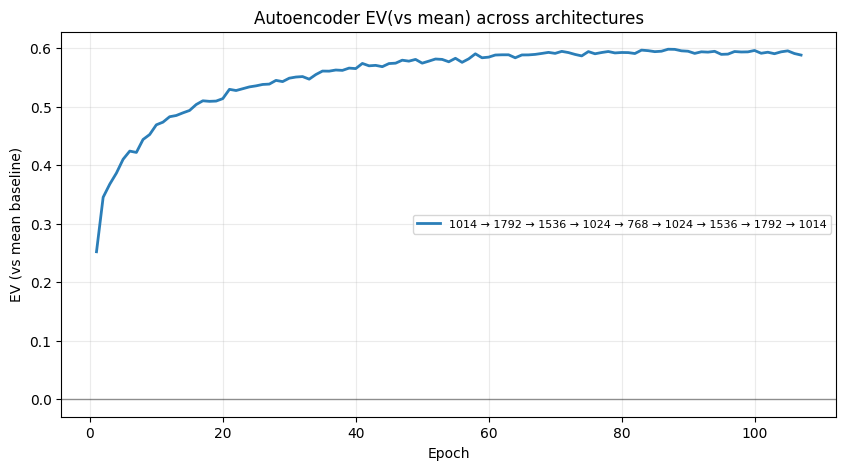

In [50]:
#plot the autoencoder runs in RUNS_JSON

with open(RUNS_JSON, "r") as f:
    runs_payload = json.load(f)

runs = runs_payload["runs"]
histories = [r["history"] for r in runs]
layers_list = [r["layers"] for r in runs]

fig, ax = plot_ae_ev(
    histories=histories,
    layers_list=layers_list,
    baseline_val_mses=None,
    title="Autoencoder EV(vs mean) across architectures",
)
plt.show()
